# Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


# Load Dataset

In [4]:
df=pd.read_csv("/content/bank.csv")

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


# Basic Exploration

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [8]:
df.describe(include='O')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [9]:
# target distribution
df['deposit'].value_counts()


,count
deposit,
no,5873
yes,5289


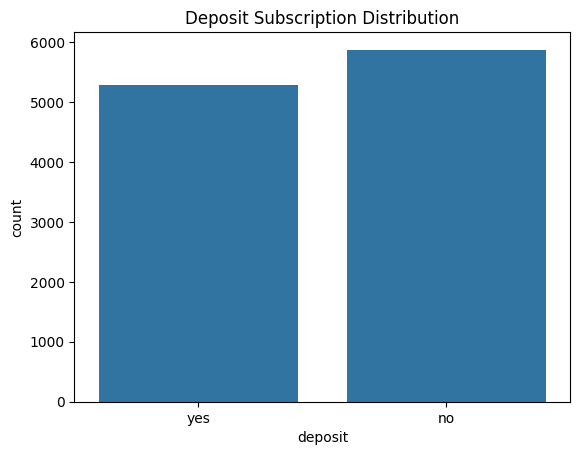

In [10]:
sns.countplot(x='deposit', data=df)
plt.title("Deposit Subscription Distribution")
plt.show()

# Data Preprocessing

In [11]:
#Encode Target Variable (deposit)
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})


In [12]:
#Separate Numerical & Categorical Features
cat_cols = df.drop('deposit', axis=1).select_dtypes(include='object').columns
num_cols = df.drop('deposit', axis=1).select_dtypes(include='int64').columns

In [13]:
# One-hot encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [14]:
# Features & target
X = df.drop('deposit', axis=1)
y = df['deposit']

In [15]:
# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# logistic regression

In [17]:
log_reg = LogisticRegression(max_iter=1000)


In [18]:
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred_log = log_reg.predict(X_test)

In [20]:
print("Logistic Regression")
accuracy_score(y_test, y_pred_log)

Logistic Regression


0.8083296014330497

In [21]:
confusion_matrix(y_test, y_pred_log)

array([[972, 194],
       [234, 833]])

# Support Vector Machine (SVM)

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)

In [ ]:

y_pred_svm = svm.predict(X_test)

print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))



# K-Nearest Neighbors (KNN)

In [24]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [25]:
y_pred_knn = knn.predict(X_test)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

KNN
Accuracy: 0.7666815942678011
[[970 196]
 [325 742]]


# Decision Tree Classifier

In [26]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.7908643081056874
[[942 224]
 [243 824]]


# Model Comparison Table

In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

In [29]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,SVM,0.836543
0,Logistic Regression,0.808330
3,Decision Tree,0.790864
2,KNN,0.766682


# Confusion Matrix Heatmap (Example: Best Model)

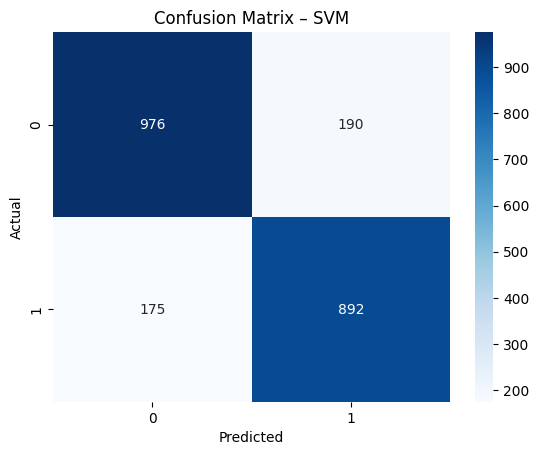

In [30]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM")
plt.show()